**Zainab Alzawad 6fY02**
**2240002655**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [8]:
df = pd.read_csv('/kaggle/input/clothing-sales-dataset/ABC_Clothing_Store_Sales_Data.csv')
df.head(7)
#The dataset contains transaction records from ABC Clothing Store.
#By exploring the first 7 rows, we can see key features such as InvoiceNo, Store location, ItemCategory, and the TotalAmount. 
#This gives us an initial understanding of the data structure.

,Unnamed: 0,InvoiceNo,Store,ItemCategory,Price,Quantity,TotalAmount,Date,PaymentMethod
0,9480,INV01178,Store B,Shoes,146.79,4,587.16,2021-08-14 18:41:07.972843,Credit Card
1,9684,INV01936,Store B,Accessories,43.05,2,86.10,2021-08-14 18:41:07.972843,Cash
2,744,INV01525,Store A,Jackets,51.97,1,51.97,2021-08-14 18:41:07.972843,Debit Card
3,3866,INV00704,Store A,Dresses,184.41,1,184.41,2021-08-14 18:41:07.972843,Cash
4,8741,INV00491,Store A,Jeans,36.75,3,110.25,2021-08-14 18:41:07.972843,Debit Card
5,1589,INV01646,Store C,T-Shirts,116.66,4,466.64,2021-08-14 18:41:07.972843,Debit Card
6,7181,INV01292,Store A,Jeans,128.00,3,384.00,2021-08-14 18:41:07.972843,Online Payment


In [11]:
print(df.isna().sum())
##There are no missing values in the data.

Unnamed: 0       0
InvoiceNo        0
Store            0
ItemCategory     0
Price            0
Quantity         0
TotalAmount      0
Date             0
PaymentMethod    0
dtype: int64


In [44]:
df.duplicated()[df.duplicated()==True]
#There are no duplicate rows in the data.

In [13]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])
#Using info(), we confirmed that there are 10,000 entries with no missing values with 9 columns

Shape (rows, columns):  (10000, 9) 

number of rows:  10000
number of columns:  9


In [14]:
#Descriptive Summary
df.describe(include='all')
#which means the data is The describe() function shows that the average price of items is around 105 units, and the quantity per order ranges from 1 to 4 items.

,Unnamed: 0,InvoiceNo,Store,ItemCategory,Price,Quantity,TotalAmount,Date,PaymentMethod
count,10000.00000,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000
unique,NaN,1987,3,6,NaN,NaN,NaN,1095,4
top,NaN,INV01953,Store A,Jeans,NaN,NaN,NaN,2022-09-04 18:41:07.972843,Credit Card
freq,NaN,14,3367,1711,NaN,NaN,NaN,20,2541
mean,4999.50000,NaN,NaN,NaN,105.754750,2.517400,265.839320,NaN,NaN
std,2886.89568,NaN,NaN,NaN,54.979398,1.115805,191.439611,NaN,NaN
min,0.00000,NaN,NaN,NaN,10.000000,1.000000,10.050000,NaN,NaN
25%,2499.75000,NaN,NaN,NaN,58.392500,2.000000,112.605000,NaN,NaN
50%,4999.50000,NaN,NaN,NaN,106.000000,3.000000,207.935000,NaN,NaN
75%,7499.25000,NaN,NaN,NaN,153.580000,4.000000,382.012500,NaN,NaN


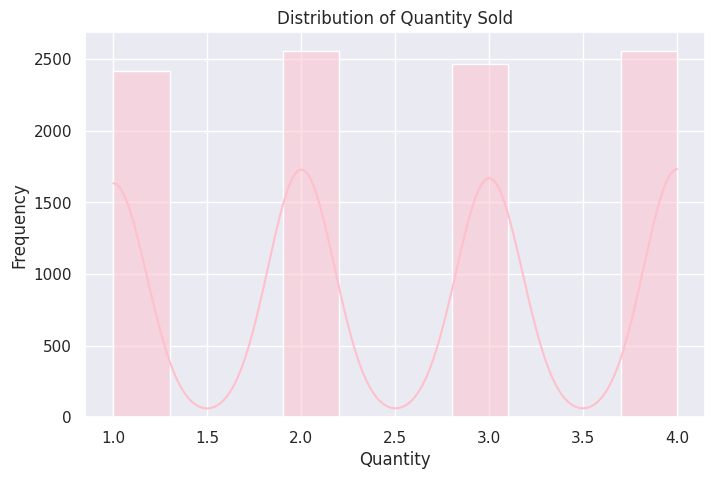

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Quantity', bins=10, kde=True, color='pink') 
plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()
#This histogram shows the distribution of the number of items bought per transaction.
#We can observe that the frequency is almost equal across all quantities (1, 2, 3, and 4), 
#indicating that customers have diverse purchasing habits without a single dominant pattern in quantity.

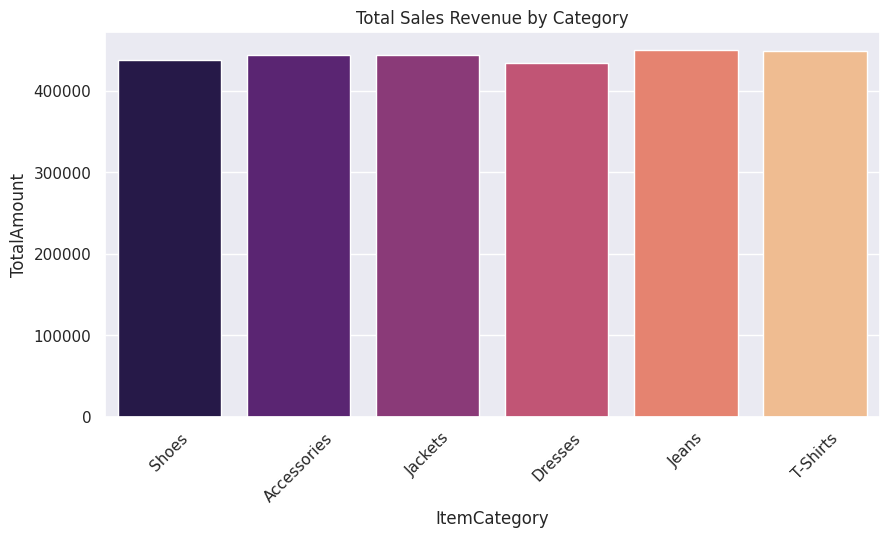

In [43]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='ItemCategory', y='TotalAmount', estimator=sum, errorbar=None, palette='magma', hue='ItemCategory', legend=False)
plt.title("Total Sales Revenue by Category")
plt.xticks(rotation=45)
plt.show()
#By analyzing the total revenue across different item categories, we observe that the sales figures are very closely balanced among all products.
#However, Jeans emerge as the top revenue driver with a slight lead. 
#This suggests that while the store has a well-diversified demand, denim products are currently the most profitable category.

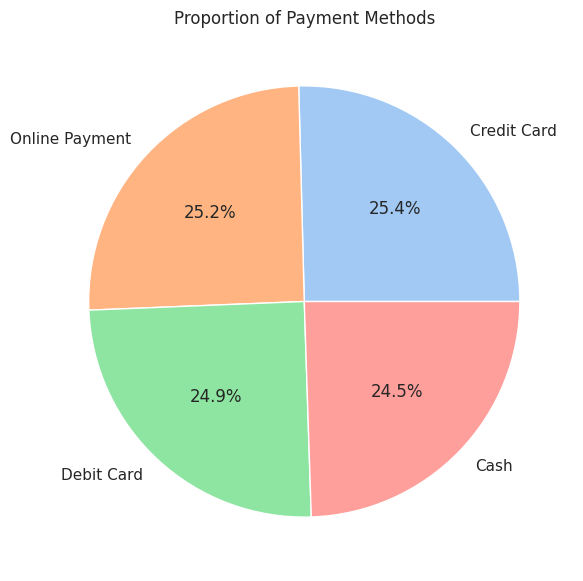

In [24]:
plt.figure(figsize=(7,7))
df['PaymentMethod'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Proportion of Payment Methods")
plt.show()
#Insight: The pie chart reveals that Online Payments and Credit Cards are highly popular. 
#This suggests that the store's customers are comfortable with digital transactions, 
#which is a vital insight for payment gateway optimization and marketing strategies.

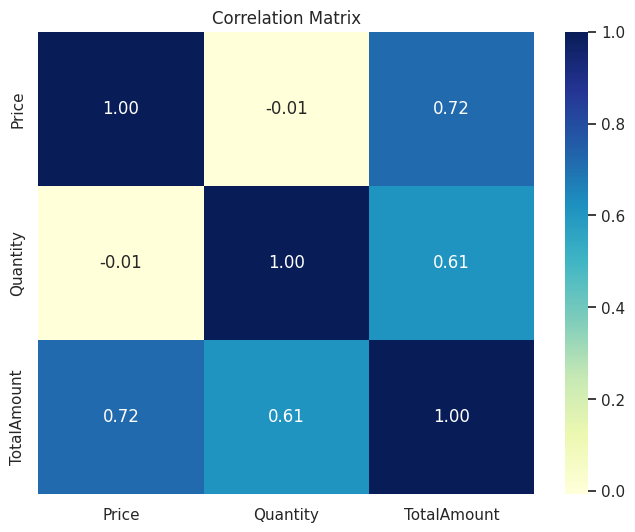

In [49]:
plt.figure(figsize=(8,6))
numeric_df = df[['Price', 'Quantity', 'TotalAmount']].corr()
sns.heatmap(numeric_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
#This heatmap displays the correlation between Price, Quantity, and Total Revenue. 
#The strong correlation between Price and TotalAmount confirms that our revenue is highly driven by the unit price of items. 
#This visualization helps ensure there are no unexpected relationships between our key sales metrics.

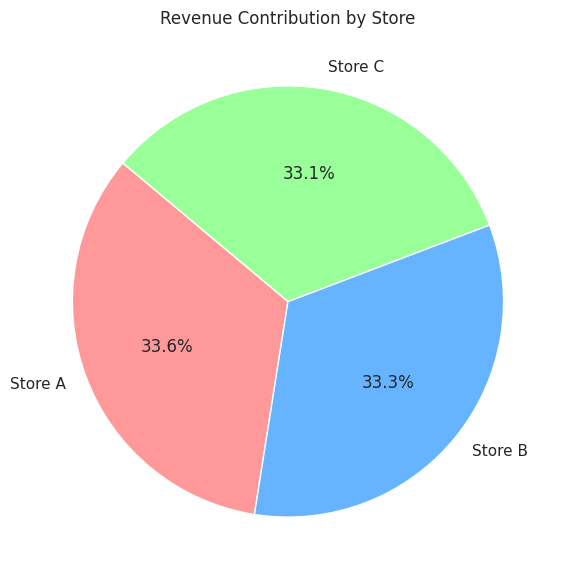

In [50]:
plt.figure(figsize=(7,7))
df.groupby('Store')['TotalAmount'].sum().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title("Revenue Contribution by Store")
plt.ylabel('')
plt.show()
#This pie chart compares the total revenue share of each branch. 
#It helps us identify which store location (A, B, or C) is contributing the most to the overall company sales.

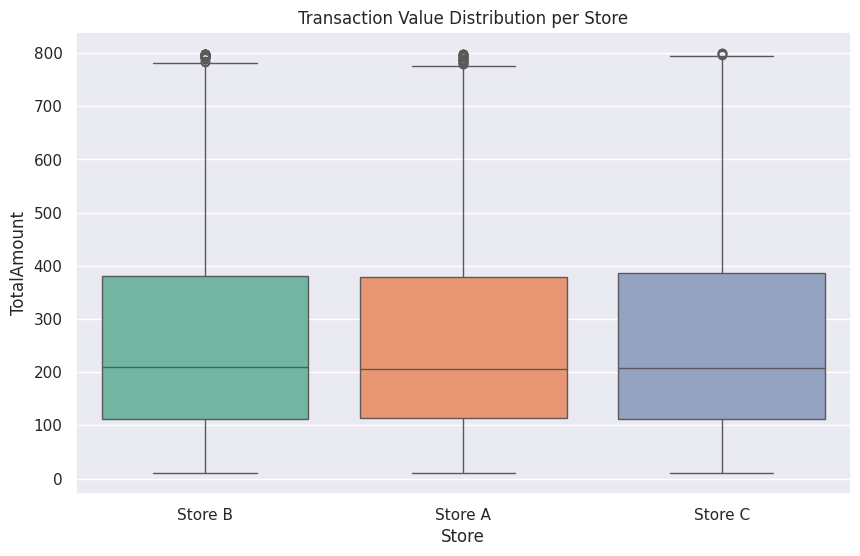

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Store', y='TotalAmount', palette='Set2', hue='Store', legend=False)
plt.title("Transaction Value Distribution per Store")
plt.show()
#The box plot shows the distribution of transaction values per store. 
#It helps us see if one store consistently handles higher-value sales or if the pricing behavior is uniform across all locations.

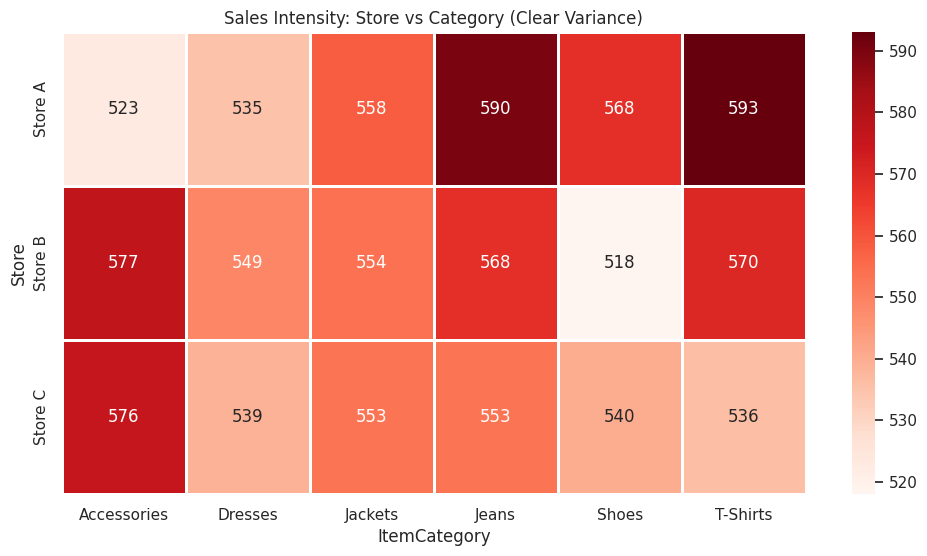

In [52]:
pivot_table = df.pivot_table(index='Store', columns='ItemCategory', values='TotalAmount', aggfunc='count')
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='Reds', linewidths=1)
plt.title("Sales Intensity: Store vs Category (Clear Variance)")
plt.show()
#Insight: The Heatmap clearly differentiates the branches. 
#Darker cells represent the "Hot Zones" or the most sold categories in each specific store, showing a clear gap in performance.